In [1]:
import os
import sys
repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

import numpy as np
import matplotlib.pyplot as plt
from utils import load_yaml
from tqdm import tqdm

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

from data_generation.differential_equations import PoissonSetup1LeastSquares
from train.train_loss import SurrogateLoss
import torch

----------------------------------------
2025-12-11 21:57:44 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/poisson_setup1/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/poisson_setup1/config_data/config_function_space.yaml"
function_space_finer_config_path = repo_path + "/configs/poisson_setup1/config_data/config_function_space_finer.yaml"
output_reduced_basis_config_path= repo_path + "/configs/poisson_setup1/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/poisson_setup1/train_dataset"
test_dataset_path = repo_path + "/results/poisson_setup1/test_dataset"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
function_space_finer_args = load_yaml(function_space_finer_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
poisson_least_squares = PoissonSetup1LeastSquares(mesh_args, function_space_args)

In [3]:
num_basis_list = [2**i for i in range(8)]
print(f'num basis list: {num_basis_list}')

num basis list: [1, 2, 4, 8, 16, 32, 64, 128]


In [4]:
num_samples = 500
compute_squared_hdiv_h1_norm = poisson_least_squares.compute_squared_hdiv_h1_norm
mesh = poisson_least_squares.mesh
Vh = poisson_least_squares.Vh

In [5]:
reduced_basis_mse_error_record = np.zeros((len(num_basis_list), num_samples))

In [6]:
sigma_u_dof = np.load(test_dataset_path+'/sigma_u_dof_finer.npy')[:num_samples]
pod_basis_dof = np.load(test_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']] 
reference_reduced_minimizers = np.load(test_dataset_path+'/reference_reduced_minimizers.npy')[:num_samples]

In [7]:
# Make sure two function spaces are defined on the same mesh
u_element = basix.ufl.element(family=function_space_finer_args["u"]["family"],
                              cell=mesh_args["mesh_cell_type"],
                              degree=function_space_finer_args["u"]["degree"])
sigma_element = basix.ufl.element(family=function_space_finer_args["sigma"]["family"],
                                  cell=mesh_args["mesh_cell_type"],
                                  degree=function_space_finer_args["sigma"]["degree"])
sigma_u_element = basix.ufl.mixed_element([sigma_element, u_element])
finer_Vh = {
    'sigma_u': dolfinx.fem.functionspace(mesh, sigma_u_element)
}

In [8]:
for i, num_basis in enumerate(tqdm(num_basis_list)):
    reduced_basis_sigma_u_dof = reference_reduced_minimizers[:, :num_basis] @ pod_basis_dof[:, :num_basis].T
    for j, sample_index in enumerate(tqdm(range(num_samples))):
        sigma_u_label_fc = dolfinx.fem.Function(finer_Vh['sigma_u'])
        sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]
        sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
        u_label_fc = sigma_u_label_fc.sub(1).collapse()

        sigma_u_low_rank_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_low_rank_fc.x.array[:] = reduced_basis_sigma_u_dof[j]
        sigma_label_low_rank_fc = sigma_u_low_rank_fc.sub(0).collapse()
        u_label_low_rank_fc = sigma_u_low_rank_fc.sub(1).collapse()

        reduced_basis_mse_error_record[i, j] = compute_squared_hdiv_h1_norm(sigma_label_fc - sigma_label_low_rank_fc, u_label_fc - u_label_low_rank_fc)

100%|██████████| 8/8 [05:26<00:00, 40.77s/it]


In [9]:
mean_reduced_basis_mse_error_record = np.mean(reduced_basis_mse_error_record, axis=1)

In [10]:
mean_reduced_basis_mse_error_record

array([0.06529809, 0.05576674, 0.04168764, 0.02219862, 0.00321682,
       0.00062503, 0.00018927, 0.00014566])

## RB loss 

In [11]:
pod_basis_dof = np.load(test_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']]
reference_reduced_minimizers = np.load(test_dataset_path+'/reference_reduced_minimizers.npy')[:,:output_reduced_basis_args['num_basis']]

In [12]:
dtype = torch.float64

In [13]:
pod_basis_dof = torch.tensor(pod_basis_dof, dtype=dtype)
reference_reduced_minimizers  = torch.tensor(reference_reduced_minimizers , dtype=dtype)
quadratic_weight = torch.tensor(np.load(test_dataset_path+'/hdiv_h1_quadratic_weight.npy'), dtype=dtype)
linear_weight = torch.tensor(np.load(test_dataset_path+'/hdiv_h1_linear_weight.npy'), dtype=dtype)
bias = torch.tensor(np.load(test_dataset_path+'/hdiv_h1_bias.npy'), dtype=dtype)

In [14]:
reduced_weight_list = []
for i in range(len(quadratic_weight)):
    reduced_weight = {}
    reduced_weight['quadratic'] = quadratic_weight[i]
    reduced_weight['linear'] = linear_weight[i]
    reduced_weight['bias'] = bias[i]
    reduced_weight_list.append(reduced_weight)

In [15]:
surrogate_loss = SurrogateLoss(reduced_weight_list)

In [16]:
num_samples = 500
num_basis_list = [2**i for i in range(8)]
print("num_basis_list:", num_basis_list)
reference_surrogate_loss_record = np.zeros((len(num_basis_list), num_samples))

num_basis_list: [1, 2, 4, 8, 16, 32, 64, 128]


In [17]:
for i, num_basis in enumerate(num_basis_list):
    for j, sample_index in enumerate(range(num_samples)):
        reference_loss = surrogate_loss(reference_reduced_minimizers[sample_index], sample_index, sub_dim=num_basis)
        reference_surrogate_loss_record[i, j] = reference_loss.item()

In [20]:
mean_reference_surrogate_loss_record = np.mean(reference_surrogate_loss_record, axis=1)

In [ ]:
np.save(os.path.join(test_dataset_path, "analysis_error_compared_to_RT3xCG4_solution_mean_reduced_basis_mse_error_record.npy"), mean_reduced_basis_mse_error_record)
np.save(os.path.join(test_dataset_path, "analysis_error_compared_to_RT3xCG4_solution_mean_reference_surrogate_loss_record.npy"), mean_reference_surrogate_loss_record)

In [6]:
mean_reduced_basis_mse_error_record = np.load(os.path.join(test_dataset_path, "analysis_error_compared_to_RT3xCG4_solution_mean_reduced_basis_mse_error_record.npy"))
mean_reference_surrogate_loss_record = np.load(os.path.join(test_dataset_path, "analysis_error_compared_to_RT3xCG4_solution_mean_reference_surrogate_loss_record.npy"))

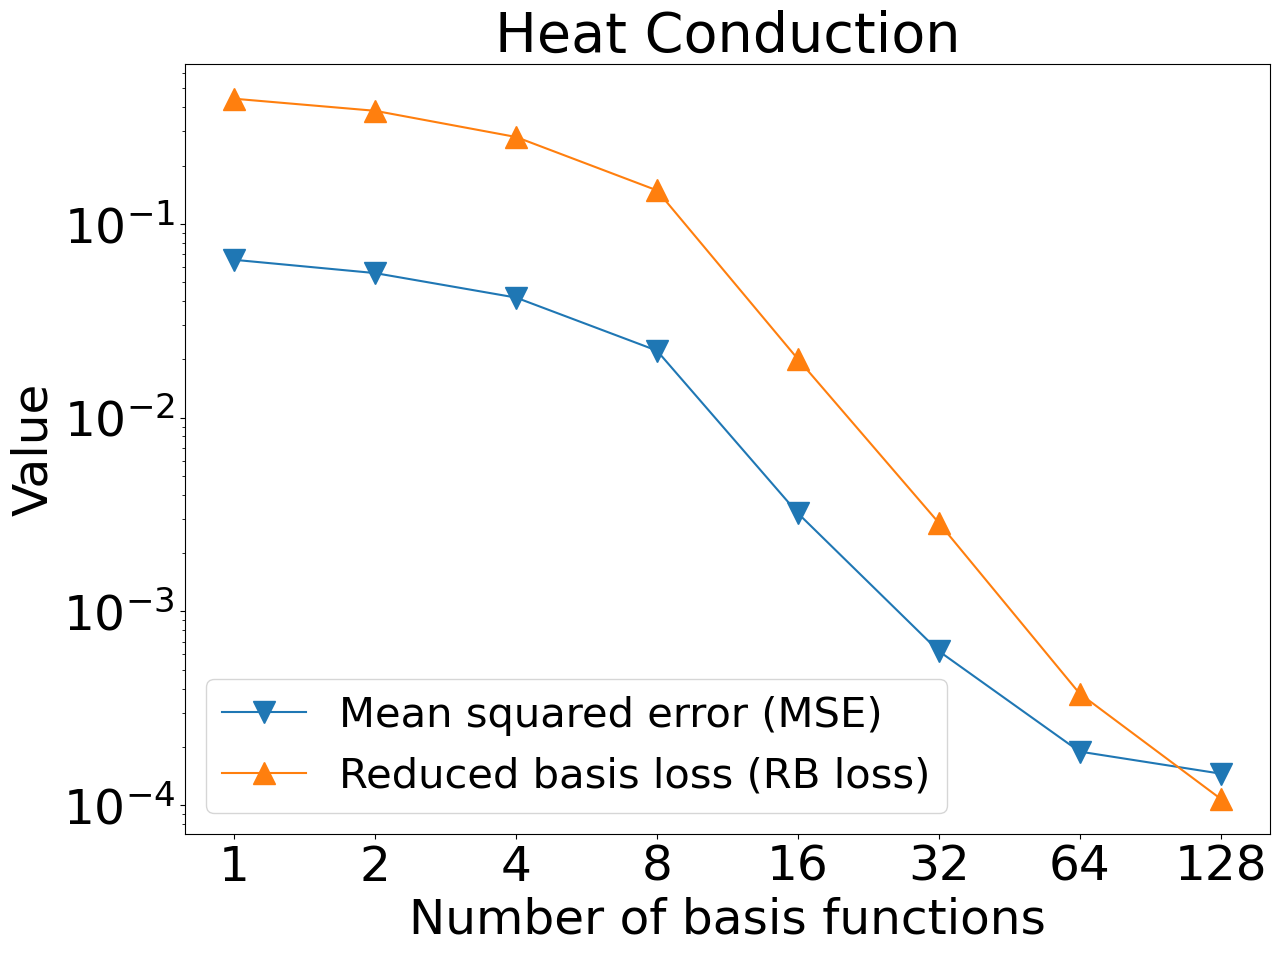

In [8]:
plt.figure(figsize=(14,10))
plt.plot(num_basis_list, mean_reduced_basis_mse_error_record, marker='v', markersize=16, label='Mean squared error (MSE)')
plt.plot(num_basis_list, mean_reference_surrogate_loss_record, marker='^', markersize=16, label='Reduced basis loss (RB loss)')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel('Number of basis functions', fontsize=35)
plt.ylabel('Value',fontsize=35)
plt.xticks(num_basis_list, num_basis_list, fontsize=35)
plt.yticks(fontsize=35)
plt.legend(fontsize=30, loc='lower left')
plt.title('Heat Conduction', fontsize=40)
plt.savefig(os.path.join(test_dataset_path, "analysis_error_compared_to_RT3xCG4_solution.png"), dpi=300, bbox_inches='tight')
plt.show()